In [ ]:
import numpy as np
import pandas as pd

# =====================================
# FUNCIÓN GENERADORA DE DATOS SINTÉTICOS
# =====================================

def generar_datos_burbuja(angulo_deg,
                          K=0.12,        # constante proporcional vT = K sin(theta)
                          tau_base=0.35, # constante de tiempo promedio
                          t_max=3,
                          dt=0.02,
                          ruido=0.0015):

    theta = np.radians(angulo_deg)

    # Velocidad terminal dependiente del ángulo
    vT = K * np.sin(theta)

    # Pequeña variación experimental en tau
    tau = tau_base + np.random.normal(0, 0.015)

    t = np.arange(0, t_max, dt)

    # Modelo físico teórico
    v = vT * (1 - np.exp(-t/tau))
    x = vT * (t + tau*np.exp(-t/tau) - tau)
    a = (vT/tau) * np.exp(-t/tau)

    # Agregar ruido experimental solo a posición (como en Tracker real)
    x = x + np.random.normal(0, ruido, size=len(x))

    return t, x

In [ ]:
angulos = [5, 15, 30, 45, 60, 75]

for angulo in angulos:
    for toma in [1, 2]:

        t, x = generar_datos_burbuja(angulo)

        df = pd.DataFrame({
            "t": t,
            "x": x
        })

        nombre = f"angulo{angulo}.txt"
        df.to_csv(nombre, index=False)

        print(f"Archivo generado correctamente: {nombre}")

Archivo generado correctamente: angulo5.txt
Archivo generado correctamente: angulo5.txt
Archivo generado correctamente: angulo15.txt
Archivo generado correctamente: angulo15.txt
Archivo generado correctamente: angulo30.txt
Archivo generado correctamente: angulo30.txt
Archivo generado correctamente: angulo45.txt
Archivo generado correctamente: angulo45.txt
Archivo generado correctamente: angulo60.txt
Archivo generado correctamente: angulo60.txt
Archivo generado correctamente: angulo75.txt
Archivo generado correctamente: angulo75.txt


In [ ]:
import numpy as np
import pandas as pd

#CONVERSION DATOS A TXT

# ==============================
# 1️⃣ Leer archivo original
# ==============================

archivo = "Datos_burbuja.txt"

# separador tabulador, decimal con coma
df = pd.read_csv(
    archivo,
    sep="\t",
    decimal=",",
    encoding="latin1",
    engine="python"
)

# eliminar columnas vacías
df = df.dropna(axis=1, how='all')

# renombrar primera columna
df = df.rename(columns={df.columns[0]: "x"})

# ==============================
# 2️⃣ Ángulos presentes
# ==============================

angulos = [5, 15, 30, 45, 60, 75, 87]

# ==============================
# 3️⃣ Extraer datos por ángulo
# ==============================

for i, ang in enumerate(angulos):

    # cada ángulo ocupa 3 columnas
    col_inicio = 1 + i*3

    t_acum = df.iloc[:, col_inicio + 1]   # segunda columna del bloque
    x = df["x"]

    # crear nuevo dataframe
    nuevo = pd.DataFrame({
        "t": t_acum,
        "x": x
    })

    # eliminar filas vacías
    nuevo = nuevo.dropna()

    # guardar archivo
    nombre_archivo = f"angulo{ang}.txt"
    nuevo.to_csv(nombre_archivo, sep="\t", index=False)

    print(f"Archivo generado: {nombre_archivo}")

print("\n✅ Conversión completada correctamente.")


Archivo generado: angulo5.txt
Archivo generado: angulo15.txt
Archivo generado: angulo30.txt
Archivo generado: angulo45.txt
Archivo generado: angulo60.txt
Archivo generado: angulo75.txt
Archivo generado: angulo87.txt

✅ Conversión completada correctamente.


Velocidad terminal ≈ 6.8548


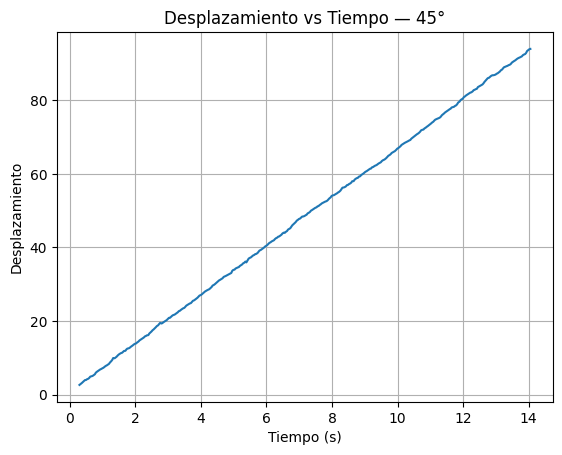

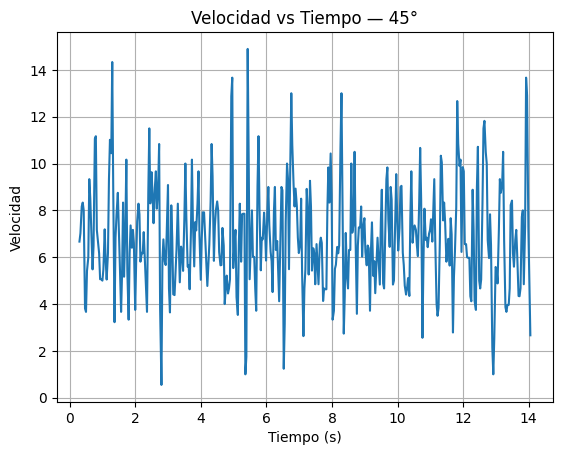

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1️⃣ Leer archivo
# ==============================

df = pd.read_csv(
    "angulo45.txt",   # tu archivo
    sep="\t",
    decimal=","
)

df.columns = ["t", "x"]

# ==============================
# 2️⃣ Convertir a numérico
# ==============================

df["t"] = pd.to_numeric(df["t"])
df["x"] = pd.to_numeric(df["x"])

# ==============================
# 3️⃣ Calcular velocidad
# ==============================

df["v"] = np.gradient(df["x"], df["t"])

# ==============================
# 4️⃣ Determinar velocidad terminal
# (últimos 30% de datos)
# ==============================

n = len(df)
v_terminal = df["v"].iloc[int(0.7*n):].mean()

print(f"Velocidad terminal ≈ {v_terminal:.4f}")

# ==============================
# 5️⃣ Gráficas consistentes
# ==============================

plt.figure()
plt.plot(df["t"], df["x"])
plt.xlabel("Tiempo (s)")
plt.ylabel("Desplazamiento")
plt.title("Desplazamiento vs Tiempo — 45°")
plt.grid()
plt.show()

plt.figure()
plt.plot(df["t"], df["v"])
plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad")
plt.title("Velocidad vs Tiempo — 45°")
plt.grid()
plt.show()